# 02 Basic Strategies



# Baseline Experiment (No Federation, All Data, Kaggle-Preprocessed)

This notebook runs a **single global baseline model** using the Kaggle-preprocessed ASHRAE data.
It does not split by clients or run any federated aggregation.


## 1) Imports and Reproducibility

In [1]:
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cpu


## 2) Load Kaggle-Preprocessed Files

In [2]:
TRAIN_PATH = Path('ashrae/train.cleaned_isamu_matt.building_mean_y_ge_1.csv')
BMETA_PATH = Path('ashrae/building_metadata.csv')
WTRAIN_PATH = Path('ashrae/weather_train.cleaned.csv')

train = pd.read_csv(TRAIN_PATH)
bmeta = pd.read_csv(BMETA_PATH)
wtrain = pd.read_csv(WTRAIN_PATH)

train['timestamp'] = pd.to_datetime(train['timestamp'])
wtrain['timestamp'] = pd.to_datetime(wtrain['timestamp'])

# Electricity only
train = train[train['meter'] == 0].copy()

meta_extra = [c for c in bmeta.columns if c not in train.columns]
if meta_extra:
    train = train.merge(bmeta[['building_id'] + meta_extra], on='building_id', how='left')

df = train.merge(wtrain, on=['site_id', 'timestamp'], how='left')
df = df.sort_values(['building_id', 'timestamp']).reset_index(drop=True)

print('Merged shape:', df.shape)
df.head()


Merged shape: (11362529, 16)


,building_id,meter,timestamp,meter_reading,site_id,square_feet,primary_use,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,7432.0,Education,2008.0,NaN,19.4,4.0,19.4,0.0,1019.7,0.0,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,7432.0,Education,2008.0,NaN,21.1,6.0,21.1,-1.0,1019.4,0.0,0.0
2,0,0,2016-01-01 02:00:00,0.0,0,7432.0,Education,2008.0,NaN,21.1,6.0,21.1,0.0,1018.8,210.0,1.5
3,0,0,2016-01-01 03:00:00,0.0,0,7432.0,Education,2008.0,NaN,20.6,6.0,20.0,0.0,1018.1,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,7432.0,Education,2008.0,NaN,21.1,6.0,20.6,0.0,1019.0,290.0,1.5


## 3) Feature Engineering

In [3]:
df['hour'] = df['timestamp'].dt.hour
df['dow'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = (df['dow'] >= 5).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['log_sqft'] = np.log1p(df['square_feet'].fillna(df['square_feet'].median()))
if 'year_built' in df.columns:
    df['year_built'] = df['year_built'].fillna(df['year_built'].median())
else:
    df['year_built'] = 2000
df['building_age'] = 2017 - df['year_built']
if 'floor_count' in df.columns:
    df['floor_count'] = df['floor_count'].fillna(1)
else:
    df['floor_count'] = 1

if 'primary_use' in df.columns:
    df['primary_use_enc'] = df['primary_use'].astype('category').cat.codes
else:
    df['primary_use_enc'] = 0

weather_cols = [
    'air_temperature', 'dew_temperature', 'wind_speed', 'cloud_coverage',
    'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction'
]
for c in weather_cols:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())
    else:
        df[c] = 0.0

for lag in [1, 24]:
    df[f'lag_{lag}'] = df.groupby('building_id')['meter_reading'].shift(lag)
df['roll24_mean'] = df.groupby('building_id')['meter_reading'].shift(1).rolling(24).mean()
df['roll24_std'] = df.groupby('building_id')['meter_reading'].shift(1).rolling(24).std()

df['y'] = np.log1p(df['meter_reading'].clip(lower=0))

for _c in ['lag_1', 'lag_24', 'roll24_mean', 'roll24_std']:
    df[_c] = df[_c].astype('float32')
valid_rows = df[['lag_1', 'lag_24', 'roll24_mean', 'roll24_std']].notna().all(axis=1).to_numpy()
df = df.loc[valid_rows].copy()
df.reset_index(drop=True, inplace=True)
print('After FE shape:', df.shape)


After FE shape: (11329481, 34)


## 4) Time-Aware Split (Per Building, Then Concatenate)

In [4]:
TRAIN_FRAC = 0.75
VAL_FRAC = 0.10
MIN_ROWS_PER_BUILDING = 1000
COLD_START_RATIO = 0.20

FEATURES = [
    'site_id', 'building_id', 'primary_use_enc',
    'hour', 'dow', 'month', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'log_sqft', 'building_age', 'floor_count',
    'lag_1', 'lag_24', 'roll24_mean', 'roll24_std',
] + weather_cols
TARGET = 'y'

train_parts, val_parts, test_parts = [], [], []
kept_buildings = []

for bid, d in df.groupby('building_id', sort=False):
    d = d.sort_values('timestamp').reset_index(drop=True)
    if len(d) < MIN_ROWS_PER_BUILDING:
        continue

    n = len(d)
    n_train = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)

    tr = d.iloc[:n_train].copy()
    va = d.iloc[n_train:n_train+n_val].copy()
    te = d.iloc[n_train+n_val:].copy()

    if len(tr) < 200 or len(te) < 100:
        continue

    train_parts.append(tr)
    val_parts.append(va)
    test_parts.append(te)
    kept_buildings.append(bid)

train_df = pd.concat(train_parts, ignore_index=True)
val_df = pd.concat(val_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

rng = np.random.default_rng(SEED)
n_cold = max(1, int(COLD_START_RATIO * len(kept_buildings)))
cold_buildings = set(rng.choice(np.array(kept_buildings), size=n_cold, replace=False).tolist())
warm_buildings = set(kept_buildings) - cold_buildings

train_days_df = (
    train_df.groupby('building_id')['timestamp']
    .agg(['min', 'max', 'count'])
    .rename(columns={'count': 'train_rows'})
    .reset_index()
)
train_days_df['train_days'] = (train_days_df['max'] - train_days_df['min']).dt.days + 1

print('Buildings used:', len(kept_buildings))
print('Cold/Warm buildings:', len(cold_buildings), len(warm_buildings))
print('Train/Val/Test shapes:', train_df.shape, val_df.shape, test_df.shape)
print('Train-day coverage summary (all buildings):')
display(train_days_df['train_days'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))


Buildings used: 1375
Cold/Warm buildings: 275 1100
Train/Val/Test shapes: (8495871, 34) (1132184, 34) (1700383, 34)
Train-day coverage summary (all buildings):


count    1375.000000
mean      274.989091
std        19.989641
min        71.000000
10%       274.000000
25%       274.000000
50%       274.000000
75%       274.000000
90%       284.600000
max       350.000000
Name: train_days, dtype: float64

## 5) Scale Features and Build DataLoaders

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURES].values)
X_val = scaler.transform(val_df[FEATURES].values)
X_test = scaler.transform(test_df[FEATURES].values)

y_train = train_df[TARGET].values.astype(np.float32)
y_val = val_df[TARGET].values.astype(np.float32)
y_test = test_df[TARGET].values.astype(np.float32)

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 1024
train_loader = DataLoader(TabularDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TabularDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TabularDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print('Feature dimension:', X_train.shape[1])


Feature dimension: 27


## 6) Global Baseline Model (MLP, No Federation)

In [6]:
class GlobalMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)


def make_model(in_dim):
    return GlobalMLP(in_dim).to(DEVICE)


def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    loss_fn = nn.MSELoss()
    losses = []
    ys, ps = [], []

    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        pred = model(Xb)
        loss = loss_fn(pred, yb)

        if train_mode:
            loss.backward()
            optimizer.step()

        losses.append(loss.item())
        ys.append(yb.detach().cpu().numpy().reshape(-1))
        ps.append(pred.detach().cpu().numpy().reshape(-1))

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return float(np.mean(losses)), mae, rmse


def fit_model(train_loader, val_loader, in_dim, epochs=10, lr=1e-3, verbose=True):
    model = make_model(in_dim)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []

    for ep in range(1, epochs + 1):
        tr_loss, tr_mae, tr_rmse = run_epoch(model, train_loader, optimizer=opt)
        va_loss, va_mae, va_rmse = run_epoch(model, val_loader, optimizer=None)
        hist.append((ep, tr_loss, va_loss, tr_mae, va_mae, tr_rmse, va_rmse))
        if verbose:
            print(f'Epoch {ep:02d} | tr_loss={tr_loss:.4f} va_loss={va_loss:.4f} | tr_mae={tr_mae:.4f} va_mae={va_mae:.4f}')

    return model, hist


BASELINE_EPOCHS = 6
model, baseline_hist = fit_model(
    train_loader=train_loader,
    val_loader=val_loader,
    in_dim=X_train.shape[1],
    epochs=BASELINE_EPOCHS,
    lr=1e-3,
    verbose=True,
)


Epoch 01 | tr_loss=0.2279 va_loss=0.0521 | tr_mae=0.3093 va_mae=0.1159
Epoch 02 | tr_loss=0.0761 va_loss=0.0521 | tr_mae=0.1731 va_mae=0.1087
Epoch 03 | tr_loss=0.0637 va_loss=0.0421 | tr_mae=0.1471 va_mae=0.1019
Epoch 04 | tr_loss=0.0609 va_loss=0.0418 | tr_mae=0.1417 va_mae=0.1004
Epoch 05 | tr_loss=0.0595 va_loss=0.0421 | tr_mae=0.1397 va_mae=0.1002
Epoch 06 | tr_loss=0.0584 va_loss=0.0436 | tr_mae=0.1382 va_mae=0.1006


## 7) Evaluate on Test Set

In [7]:
def predict_loader(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE)
            pred = model(Xb).cpu().numpy().reshape(-1)
            ys.append(yb.numpy().reshape(-1))
            ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)


def metric_bundle(y_true_log, y_pred_log):
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = math.sqrt(mean_squared_error(y_true_log, y_pred_log))

    y_true_raw = np.expm1(y_true_log)
    y_pred_raw = np.expm1(y_pred_log)

    mae_raw = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse_raw = math.sqrt(mean_squared_error(y_true_raw, y_pred_raw))

    mean_true = np.mean(y_true_raw)
    cvrmse = (rmse_raw / mean_true * 100) if mean_true != 0 else np.nan

    denom = np.sum(np.abs(y_true_raw))
    wape = (np.sum(np.abs(y_true_raw - y_pred_raw)) / denom * 100) if denom != 0 else np.nan

    return {
        'mae_log': mae_log,
        'rmse_log': rmse_log,
        'mae_raw': mae_raw,
        'rmse_raw': rmse_raw,
        'cvrmse': cvrmse,
        'wape': wape,
    }


y_true, y_pred = predict_loader(model, test_loader)
base_metrics = metric_bundle(y_true, y_pred)

y_true_raw = np.expm1(y_true)
y_pred_raw = np.expm1(y_pred)

is_cold_test = test_df['building_id'].isin(cold_buildings).to_numpy()
is_warm_test = ~is_cold_test

warm_metrics = metric_bundle(y_true[is_warm_test], y_pred[is_warm_test])
cold_metrics = metric_bundle(y_true[is_cold_test], y_pred[is_cold_test])

metrics = pd.DataFrame([
    {'split': 'overall', 'MAE (log1p)': base_metrics['mae_log'], 'RMSE (log1p)': base_metrics['rmse_log'], 'CVRMSE (%)': base_metrics['cvrmse'], 'WAPE (%)': base_metrics['wape']},
    {'split': 'warm', 'MAE (log1p)': warm_metrics['mae_log'], 'RMSE (log1p)': warm_metrics['rmse_log'], 'CVRMSE (%)': warm_metrics['cvrmse'], 'WAPE (%)': warm_metrics['wape']},
    {'split': 'cold', 'MAE (log1p)': cold_metrics['mae_log'], 'RMSE (log1p)': cold_metrics['rmse_log'], 'CVRMSE (%)': cold_metrics['cvrmse'], 'WAPE (%)': cold_metrics['wape']},
])
display(metrics)


,split,MAE (log1p),RMSE (log1p),CVRMSE (%),WAPE (%)
0,overall,0.101692,0.202947,328.629944,12.189950
1,warm,0.101098,0.202205,347.358521,13.190103
2,cold,0.104070,0.205891,18.348124,6.686745


## 8) Save Predictions

In [8]:
pred_df = test_df[['building_id', 'site_id', 'timestamp', 'meter_reading']].copy()
pred_df['y_true_log1p'] = y_true
pred_df['y_pred_log1p'] = y_pred
pred_df['y_true_raw'] = y_true_raw
pred_df['y_pred_raw'] = y_pred_raw

out_dir = Path('saved_models')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'baseline_no_federation_all_data_predictions.csv'
pred_df.to_csv(out_path, index=False)

print('Saved predictions to:', out_path)
pred_df.head()


Saved predictions to: saved_models\baseline_no_federation_all_data_predictions.csv


,building_id,site_id,timestamp,meter_reading,y_true_log1p,y_pred_log1p,y_true_raw,y_pred_raw
0,0,0,2016-11-23 22:00:00,68.420090,4.240176,4.027616,68.420082,55.126919
1,0,0,2016-11-23 23:00:00,68.219910,4.237288,4.035190,68.219902,55.553669
2,0,0,2016-11-24 00:00:00,68.219910,4.237288,4.138264,68.219902,61.693871
3,0,0,2016-11-24 01:00:00,68.820175,4.245923,4.100832,68.820175,59.390541
4,0,0,2016-11-24 02:00:00,68.219910,4.237288,4.108208,68.219902,59.837608


## 9) Quick Diagnostic Plot

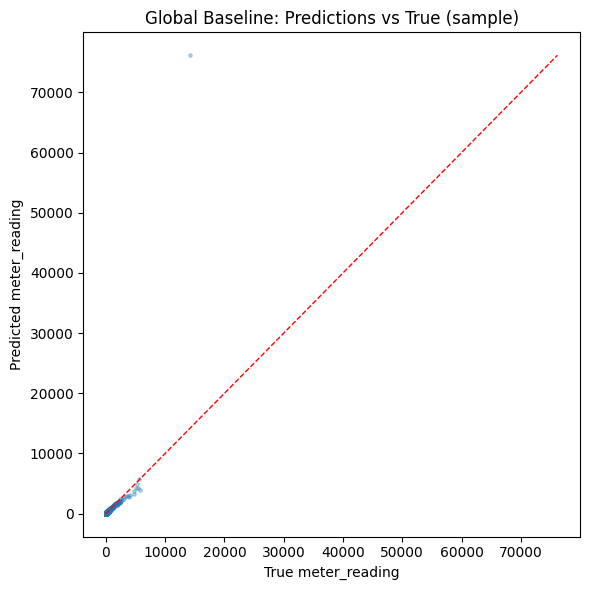

In [9]:
plt.figure(figsize=(6, 6))
sample_n = min(5000, len(y_true_raw))
idx = np.random.choice(len(y_true_raw), size=sample_n, replace=False)
plt.scatter(y_true_raw[idx], y_pred_raw[idx], s=6, alpha=0.3)
m = max(np.max(y_true_raw[idx]), np.max(y_pred_raw[idx]))
plt.plot([0, m], [0, m], 'r--', linewidth=1)
plt.xlabel('True meter_reading')
plt.ylabel('Predicted meter_reading')
plt.title('Global Baseline: Predictions vs True (sample)')
plt.tight_layout()
plt.show()


## 10) Cold-Start Days Sweep (No Federation)

We restrict only cold-start buildings to their first *N* days of training data, retrain one global model, and evaluate warm/cold/overall performance.


Max available train days: 350
Candidate days: [1, 2, 3, 5, 7, 10, 14, 21, 30, 45, 60, 90, 120, 150, 180, 240, 274, 277, 285, 300]
Selected days for sweep: [1, 2, 3, 5, 7, 10, 14, 21, 30, 45, 60, 90, 120, 150, 180, 240, 274]


,days,all_buildings_cov_%,cold_buildings_cov_%
0,1,100.000000,100.000000
1,2,100.000000,100.000000
2,3,100.000000,100.000000
3,5,100.000000,100.000000
4,7,100.000000,100.000000
5,10,100.000000,100.000000
6,14,100.000000,100.000000
7,21,100.000000,100.000000
8,30,100.000000,100.000000
9,45,100.000000,100.000000


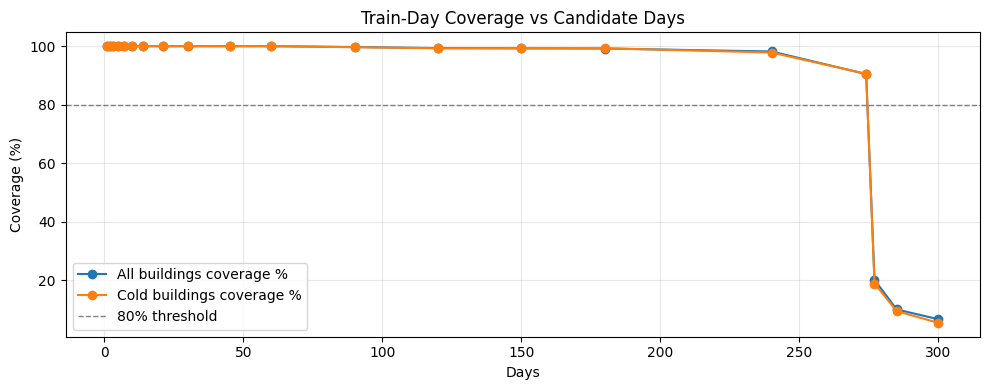

In [10]:
base_days = [1, 2, 3, 5, 7, 10, 14, 21, 30, 45, 60, 90, 120, 150, 180, 240, 300]
q_days = (
    train_days_df['train_days']
    .quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
    .round()
    .astype(int)
    .tolist()
)

max_days = int(train_days_df['train_days'].max())
candidate_days = sorted({d for d in base_days + q_days if 1 <= d <= max_days})

coverage_rows = []
for d in candidate_days:
    all_cov = (train_days_df['train_days'] >= d).mean() * 100
    cold_cov = (
        train_days_df[train_days_df['building_id'].isin(cold_buildings)]['train_days'] >= d
    ).mean() * 100
    coverage_rows.append({'days': d, 'all_buildings_cov_%': all_cov, 'cold_buildings_cov_%': cold_cov})

coverage_df = pd.DataFrame(coverage_rows)

selected_days = coverage_df.loc[coverage_df['cold_buildings_cov_%'] >= 80, 'days'].tolist()

for anchor in [3, 7, 14, 30, 60, 90]:
    if anchor in candidate_days and anchor not in selected_days:
        selected_days.append(anchor)
selected_days = sorted(selected_days)

print('Max available train days:', max_days)
print('Candidate days:', candidate_days)
print('Selected days for sweep:', selected_days)
display(coverage_df)

plt.figure(figsize=(10, 4))
plt.plot(coverage_df['days'], coverage_df['all_buildings_cov_%'], marker='o', label='All buildings coverage %')
plt.plot(coverage_df['days'], coverage_df['cold_buildings_cov_%'], marker='o', label='Cold buildings coverage %')
plt.axhline(80, color='gray', linestyle='--', linewidth=1, label='80% threshold')
plt.xlabel('Days')
plt.ylabel('Coverage (%)')
plt.title('Train-Day Coverage vs Candidate Days')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# def build_limited_train(days, min_rows_cold=300):
#     parts = []
#     for bid in kept_buildings:
#         d = train_df[train_df['building_id'] == bid].sort_values('timestamp').copy()
#         if bid in cold_buildings:
#             start = d['timestamp'].min()
#             d_cut = d[d['timestamp'] < (start + pd.Timedelta(days=days))].copy()
#             if len(d_cut) < min_rows_cold:
#                 d_cut = d.iloc[:min_rows_cold].copy()
#             d = d_cut
#         parts.append(d)
#     return pd.concat(parts, ignore_index=True)


# def make_loaders(train_local, val_local, test_local, features, target, batch_size=1024):
#     scaler_local = StandardScaler()
#     Xtr = scaler_local.fit_transform(train_local[features].values)
#     Xva = scaler_local.transform(val_local[features].values)
#     Xte = scaler_local.transform(test_local[features].values)

#     ytr = train_local[target].values.astype(np.float32)
#     yva = val_local[target].values.astype(np.float32)
#     yte = test_local[target].values.astype(np.float32)

#     tr_loader = DataLoader(TabularDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
#     va_loader = DataLoader(TabularDataset(Xva, yva), batch_size=batch_size, shuffle=False)
#     te_loader = DataLoader(TabularDataset(Xte, yte), batch_size=batch_size, shuffle=False)
#     return tr_loader, va_loader, te_loader


# SWEEP_EPOCHS = 6
# sweep_rows = []

# for d in selected_days:
#     print(f'Running day sweep: {d} days')
#     train_limited = build_limited_train(days=d, min_rows_cold=300)

#     tr_loader_d, va_loader_d, te_loader_d = make_loaders(
#         train_local=train_limited,
#         val_local=val_df,
#         test_local=test_df,
#         features=FEATURES,
#         target=TARGET,
#         batch_size=1024,
#     )

#     model_d, _ = fit_model(
#         train_loader=tr_loader_d,
#         val_loader=va_loader_d,
#         in_dim=len(FEATURES),
#         epochs=SWEEP_EPOCHS,
#         lr=1e-3,
#         verbose=False,
#     )

#     y_true_d, y_pred_d = predict_loader(model_d, te_loader_d)
#     m_all = metric_bundle(y_true_d, y_pred_d)

#     cold_mask = test_df['building_id'].isin(cold_buildings).to_numpy()
#     warm_mask = ~cold_mask

#     m_cold = metric_bundle(y_true_d[cold_mask], y_pred_d[cold_mask])
#     m_warm = metric_bundle(y_true_d[warm_mask], y_pred_d[warm_mask])

#     cold_rows_used = train_limited[train_limited['building_id'].isin(cold_buildings)].groupby('building_id').size()

#     sweep_rows.append({
#         'days': d,
#         'cold_rows_median': float(cold_rows_used.median()),
#         'cold_rows_min': int(cold_rows_used.min()),
#         'cold_rows_max': int(cold_rows_used.max()),
#         'overall_mae_log1p': m_all['mae_log'],
#         'warm_mae_log1p': m_warm['mae_log'],
#         'cold_mae_log1p': m_cold['mae_log'],
#         'overall_cvrmse': m_all['cvrmse'],
#         'warm_cvrmse': m_warm['cvrmse'],
#         'cold_cvrmse': m_cold['cvrmse'],
#     })

# sweep_df = pd.DataFrame(sweep_rows).sort_values('days').reset_index(drop=True)
# display(sweep_df)

# fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# axes[0].plot(sweep_df['days'], sweep_df['overall_mae_log1p'], marker='o', label='Overall MAE')
# axes[0].plot(sweep_df['days'], sweep_df['warm_mae_log1p'], marker='o', label='Warm MAE')
# axes[0].plot(sweep_df['days'], sweep_df['cold_mae_log1p'], marker='o', label='Cold MAE')
# axes[0].set_xlabel('Cold-start days used for training')
# axes[0].set_ylabel('MAE (log1p)')
# axes[0].set_title('MAE vs Cold-Start Days (No Federation)')
# axes[0].grid(alpha=0.3)
# axes[0].legend()

# axes[1].plot(sweep_df['days'], sweep_df['overall_cvrmse'], marker='o', label='Overall CVRMSE')
# axes[1].plot(sweep_df['days'], sweep_df['warm_cvrmse'], marker='o', label='Warm CVRMSE')
# axes[1].plot(sweep_df['days'], sweep_df['cold_cvrmse'], marker='o', label='Cold CVRMSE')
# axes[1].set_xlabel('Cold-start days used for training')
# axes[1].set_ylabel('CVRMSE (%)')
# axes[1].set_title('CVRMSE vs Cold-Start Days (No Federation)')
# axes[1].grid(alpha=0.3)
# axes[1].legend()

# plt.tight_layout()
# plt.show()


Selected days: [3, 7, 14, 21, 30, 45, 60]
Warm rows: 6799362 | Cold buildings: 275
Running day sweep: 3 days


C:\Users\tamar\AppData\Local\Temp\ipykernel_15096\2528153406.py:51: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pd.concat([warm_train] + cold_parts, ignore_index=True, copy=False)


Running day sweep: 7 days


C:\Users\tamar\AppData\Local\Temp\ipykernel_15096\2528153406.py:51: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pd.concat([warm_train] + cold_parts, ignore_index=True, copy=False)


Running day sweep: 14 days


...

Running day sweep: 45 days


C:\Users\tamar\AppData\Local\Temp\ipykernel_15096\2528153406.py:51: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pd.concat([warm_train] + cold_parts, ignore_index=True, copy=False)


Running day sweep: 60 days


C:\Users\tamar\AppData\Local\Temp\ipykernel_15096\2528153406.py:51: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pd.concat([warm_train] + cold_parts, ignore_index=True, copy=False)


,days,train_rows_total,cold_rows_median,cold_rows_min,cold_rows_max,overall_mae_log1p,warm_mae_log1p,cold_mae_log1p,overall_cvrmse,warm_cvrmse,cold_cvrmse
0,3,6881862,300.0,300,300,0.122041,0.122140,0.121643,965.334045,1020.464233,33.394066
1,7,6881862,300.0,300,300,0.110275,0.109577,0.113070,1065.729858,1126.643799,22.551315
2,14,6890348,336.0,300,336,0.121020,0.119883,0.125576,1614.288330,1706.585449,20.344213
3,21,6933611,504.0,300,504,0.128914,0.128486,0.130627,247.668961,261.601288,30.199633
4,30,6989446,720.0,300,720,0.102002,0.101153,0.105403,383.734253,405.616852,19.368311
5,45,7079511,1080.0,300,1080,0.120971,0.119670,0.126185,578.653259,611.689087,22.431654
6,60,7163862,1440.0,300,1440,0.122203,0.121685,0.124277,434.897858,459.685608,23.840485


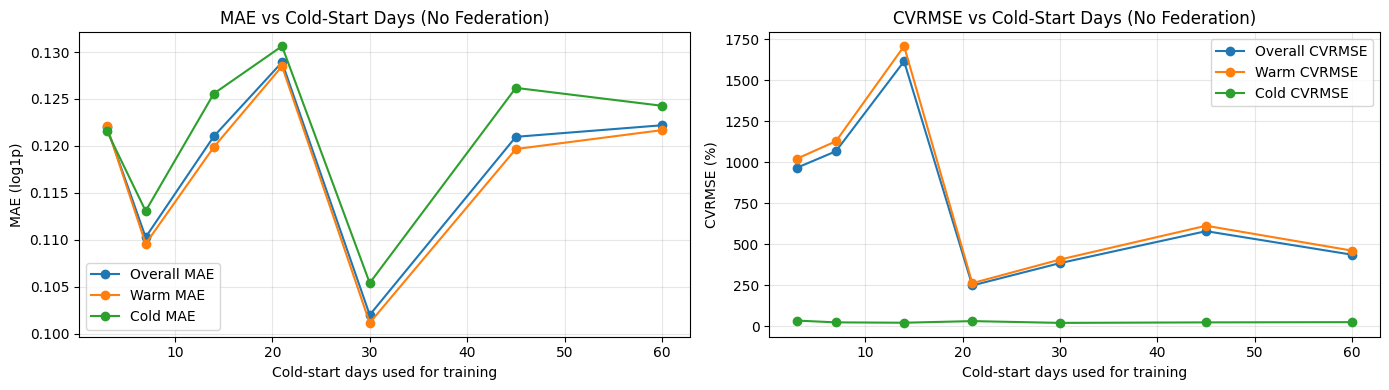

In [12]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
import torch



# -------------------------
# 1) Reduce memory footprint
# -------------------------
NEEDED_COLS = list(dict.fromkeys(FEATURES + [TARGET, "building_id", "timestamp"]))

train_small = train_df[NEEDED_COLS].copy()
val_small = val_df[NEEDED_COLS].copy()
test_small = test_df[NEEDED_COLS].copy()

for df_ in (train_small, val_small, test_small):
    float64_cols = df_.select_dtypes(include=["float64"]).columns
    if len(float64_cols) > 0:
        df_[float64_cols] = df_[float64_cols].astype("float32")

# -------------------------
# 2) Precompute warm/cold
# -------------------------
cold_set = set(cold_buildings)

warm_train = train_small.loc[~train_small["building_id"].isin(cold_set)].copy()
cold_train_by_bid = {
    bid: train_small.loc[train_small["building_id"] == bid].sort_values("timestamp")
    for bid in cold_set
}

cold_mask = test_small["building_id"].isin(cold_set).to_numpy()
warm_mask = ~cold_mask

def build_limited_train(days, min_rows_cold=300):
    cold_parts = []
    for bid, d in cold_train_by_bid.items():
        if len(d) == 0:
            continue
        start = d["timestamp"].iloc[0]
        d_cut = d.loc[d["timestamp"] < (start + pd.Timedelta(days=days))]
        if len(d_cut) < min_rows_cold:
            d_cut = d.iloc[:min_rows_cold]
        cold_parts.append(d_cut)

    # concat warm once + limited cold subsets
    return pd.concat([warm_train] + cold_parts, ignore_index=True, copy=False)

def make_loaders(train_local, val_local, test_local, features, target, batch_size=512):
    scaler_local = StandardScaler()

    Xtr = scaler_local.fit_transform(train_local[features].to_numpy(dtype=np.float32))
    Xva = scaler_local.transform(val_local[features].to_numpy(dtype=np.float32))
    Xte = scaler_local.transform(test_local[features].to_numpy(dtype=np.float32))

    ytr = train_local[target].to_numpy(dtype=np.float32)
    yva = val_local[target].to_numpy(dtype=np.float32)
    yte = test_local[target].to_numpy(dtype=np.float32)

    tr_loader = DataLoader(TabularDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(TabularDataset(Xva, yva), batch_size=batch_size, shuffle=False)
    te_loader = DataLoader(TabularDataset(Xte, yte), batch_size=batch_size, shuffle=False)
    return tr_loader, va_loader, te_loader

selected_days = sorted(set(int(d) for d in selected_days if int(d) >= 1))
anchor_pref = [3, 7, 14, 21, 30, 45, 60]
selected_days = [d for d in anchor_pref if d in selected_days] or selected_days[:7]

SWEEP_EPOCHS = 3
sweep_rows = []

print("Selected days:", selected_days)
print("Warm rows:", len(warm_train), "| Cold buildings:", len(cold_train_by_bid))

for d in selected_days:
    print(f"Running day sweep: {d} days")

    train_limited = build_limited_train(days=d, min_rows_cold=300)

    tr_loader_d, va_loader_d, te_loader_d = make_loaders(
        train_local=train_limited,
        val_local=val_small,
        test_local=test_small,
        features=FEATURES,
        target=TARGET,
        batch_size=512,
    )

    model_d, _ = fit_model(
        train_loader=tr_loader_d,
        val_loader=va_loader_d,
        in_dim=len(FEATURES),
        epochs=SWEEP_EPOCHS,
        lr=1e-3,
        verbose=False,
    )

    y_true_d, y_pred_d = predict_loader(model_d, te_loader_d)

    m_all = metric_bundle(y_true_d, y_pred_d)
    m_cold = metric_bundle(y_true_d[cold_mask], y_pred_d[cold_mask])
    m_warm = metric_bundle(y_true_d[warm_mask], y_pred_d[warm_mask])

    cold_rows_used = train_limited.loc[
        train_limited["building_id"].isin(cold_set)
    ].groupby("building_id").size()

    sweep_rows.append({
        "days": int(d),
        "train_rows_total": int(len(train_limited)),
        "cold_rows_median": float(cold_rows_used.median()) if len(cold_rows_used) else np.nan,
        "cold_rows_min": int(cold_rows_used.min()) if len(cold_rows_used) else 0,
        "cold_rows_max": int(cold_rows_used.max()) if len(cold_rows_used) else 0,
        "overall_mae_log1p": float(m_all["mae_log"]),
        "warm_mae_log1p": float(m_warm["mae_log"]),
        "cold_mae_log1p": float(m_cold["mae_log"]),
        "overall_cvrmse": float(m_all["cvrmse"]),
        "warm_cvrmse": float(m_warm["cvrmse"]),
        "cold_cvrmse": float(m_cold["cvrmse"]),
    })

    del train_limited, tr_loader_d, va_loader_d, te_loader_d, model_d, y_true_d, y_pred_d, m_all, m_cold, m_warm, cold_rows_used
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sweep_df = pd.DataFrame(sweep_rows).sort_values("days").reset_index(drop=True)
display(sweep_df)

# -------------------------
# 3) Plots
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sweep_df["days"], sweep_df["overall_mae_log1p"], marker="o", label="Overall MAE")
axes[0].plot(sweep_df["days"], sweep_df["warm_mae_log1p"], marker="o", label="Warm MAE")
axes[0].plot(sweep_df["days"], sweep_df["cold_mae_log1p"], marker="o", label="Cold MAE")
axes[0].set_xlabel("Cold-start days used for training")
axes[0].set_ylabel("MAE (log1p)")
axes[0].set_title("MAE vs Cold-Start Days (No Federation)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(sweep_df["days"], sweep_df["overall_cvrmse"], marker="o", label="Overall CVRMSE")
axes[1].plot(sweep_df["days"], sweep_df["warm_cvrmse"], marker="o", label="Warm CVRMSE")
axes[1].plot(sweep_df["days"], sweep_df["cold_cvrmse"], marker="o", label="Cold CVRMSE")
axes[1].set_xlabel("Cold-start days used for training")
axes[1].set_ylabel("CVRMSE (%)")
axes[1].set_title("CVRMSE vs Cold-Start Days (No Federation)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Notes

- This is the **non-federated baseline**: one model trained on all train splits from all buildings.
- To compare fairly with your FL notebooks, keep preprocessing and metrics identical.
- If memory is tight, sample buildings or reduce rows before training.
